In [1]:
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as patheffects
fontprops = fm.FontProperties(size=12)
from scipy import ndimage

import exspy


%matplotlib qt5

In [2]:
s = hs.load('/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/STEM-EDS A1/STEM-EDS A1.hdf5',reader= 'HSPY')

/Users/jonasfsimonsen/anaconda3/envs/pyxem/lib/python3.11/site-packages/hyperspy/io.py:651: VisibleDeprecationWarning: Loading old file version. The binned attribute has been moved from metadata.Signal to axis.is_binned. Setting this attribute for all signal axes instead.
  warnings.warn(


In [3]:
#Remove zero peak 
s.crop('depth',start=25,end=2048)

In [5]:
s.metadata

├── Acquisition_instrument
│   └── TEM
│       ├── Detector
│       │   └── EDS
│       │       ├── azimuth_angle = 0.0
│       │       ├── elevation_angle = 25.0
│       │       ├── energy_resolution_MnKa = 130.0
│       │       ├── live_time = 0.012000000476839193
│       │       └── real_time = 0.01212195853392334
│       ├── Stage
│       │   └── tilt_alpha = 0.0
│       └── beam_energy = 200.0
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.3.0
│   │       ├── io_plugin = rsciio.hspy
│   │       ├── operation = load
│   │       └── timestamp = 2026-05-14T15:35:09.720251+02:00
│   ├── date = 2026-05-13
│   ├── original_filename = STEM-EDS A1.rpl
│   ├── time = 16:00:00
│   └── title = 
└── Signal
    └── signal_type = EDS_TEM

In [4]:
s.axes_manager

Navigation axis name,size,index,offset,scale,units
x,512,0,0.0,0.00234375,μm
y,480,0,0.0,0.0023541666666666663,μm
Signal axis name,size,,offset,scale,units
depth,2023,,0.09999999999999998,0.02,keV


In [5]:
s_sum = s.sum()
s_sum.plot()

In [58]:
s_sum.axes_manager

Signal axis name,size,,offset,scale,units
depth,2023,,0.09999999999999998,0.02,keV


In [6]:
s.set_elements(["O", "Ru", "Cl"])
s.add_lines(['Ru_La', 'Ru_Lb1', "Ru_Ka","Ru_Kb", 'O_Ka', 'Cl_Ka', 'Cl_Kb', 'Si_Ka', 'N_Ka'])
s.sum().plot(xray_lines=True)

In [9]:
#check that the integration lines does not overlap
s.sum().plot(xray_lines=True,integration_windows=0.55)

In [6]:
#Estimate background windows
bw = s.estimate_background_windows(line_width=[1.80, 3.2])


In [5]:
s_binned = s.rebin(scale=(4, 4, 1))
lines = s_binned.get_lines_intensity()
lines

[<BaseSignal, title: X-ray line intensity of : Cl_Ka at 2.62 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Cl_Kb at 2.82 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : N_Ka at 0.39 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : O_Ka at 0.52 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Ru_Ka at 19.28 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Ru_Kb at 21.66 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Ru_La at 2.56 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Ru_Lb1 at 2.68 keV, dimensions: (128, 120|)>,
 <BaseSignal, title: X-ray line intensity of : Si_Ka at 1.74 keV, dimensions: (128, 120|)>]

In [11]:
s_sum2 = s.sum()
s_sum2.plot(integration_windows=0.55, background_windows=bw)

In [6]:
s_Cl = (lines[0] + lines[1]).T # all Cl signal
s_N = lines[2].T # N signal
s_O = lines[3].T # O signal
s_Ru_Ka = (lines[4]+lines[5]).T # Ru_Ka signal
s_Ru_Kb = (lines[6]+lines[7]).T # Ru_Kb signal
s_Si = lines[8].T # Si signal

In [ ]:
maps = [s_Cl, s_O, s_Ru_Ka]
colors = ["Greens_r", "Blues_r", "Oranges_r"]
labels = ["Cl", "O", "Ru"]
for i, map in enumerate(maps):
    fig,ax = plt.subplots(1, figsize=(10, 10))
    norm_data = (map.data - np.min(map.data)) / (np.max(map.data) - np.min(map.data))
    cax = ax.imshow(norm_data, extent=map.axes_manager.signal_extent,  cmap=colors[i])
    cbar =fig.colorbar(cax, ax = ax,aspect = 7)
    cbar.ax.tick_params(labelsize=24)
    ax.set_xticks([])
    ax.set_yticks([])


    scalebar = AnchoredSizeBar(
        transform=ax.transData,
        size=0.25, #250nm
        label='',#r'6 nm$^{-1}$',
        loc='center',                # irrelevant when using bbox_to_anchor
        frameon=False,
        color="white",
        size_vertical=0.03,
        label_top=False,
        fontproperties=fontprops,
        bbox_to_anchor=(0.87, 0.08), # (x, y) in axes coordinates
        bbox_transform=ax.transAxes # interpret the coords in axes space
    )
    ax.add_artist(scalebar)

    fig.savefig("eds_map_" + labels[i] + "_bin4" + "_norm" +".svg", 
            bbox_inches='tight',   # Remove extra whitespace
            pad_inches=0,          # No padding
            dpi=750)
    plt.close(fig)


# STEM HAADF overview

In [2]:
s2 = hs.load('/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/20260513_STEMHAADF_x60k_20cmt_A1_img2.dm3')


In [3]:
s2.original_metadata

├── ApplicationBounds = (0, 0, 1063, 1920)
├── DocumentObjectList
│   └── TagGroup0
│       ├── AnnotationGroupList
│       │   └── TagGroup0
│       │       ├── AnnotationType = 31
│       │       ├── BackgroundColor = (0, 0, 0)
│       │       ├── BackgroundMode = 1
│       │       ├── FillMode = 1
│       │       ├── Font
│       │       │   ├── Attributes = 7
│       │       │   ├── FamilyName = Arial
│       │       │   └── Size = 19
│       │       ├── ForegroundColor = (-1, -1, -1)
│       │       ├── HasBackground = 1
│       │       ├── IsMoveable = 1
│       │       ├── IsResizable = 1
│       │       ├── IsSelectable = 1
│       │       ├── IsTranslatable = 1
│       │       ├── IsVisible = 1
│       │       ├── ObjectTags
│       │       ├── Rectangle = (979.0, 16.0, 1008.0, 201.0)
│       │       ├── TextOffsetH = 1.0
│       │       ├── TextOffsetV = 1.0
│       │       ├── TextWidth = 59.0
│       │       └── UniqueID = 11
│       ├── AnnotationType = 20
│       ├── BackgroundColor = (-1, -1, -1)
│       ├── BackgroundMode = 2
│       ├── FillMode = 1
│       ├── ForegroundColor = (-1, 0, 0)
│       ├── HasBackground = 0
│       ├── ImageDisplayInfo
│       │   ├── BrightColor = (-1, -1, -1)
│       │   ├── Brightness = 0.5
│       │   ├── CLUT <list>
│       │   │   ╠══ [0] = (0, 0, 0)
│       │   │   ╠══ [1] = (257, 257, 257)
│       │   │   ╠══ [10] = (2570, 2570, 2570)
│       │   │   ╠══ [100] = (25700, 25700, 25700)
│       │   │   ╠══ [101] = (25957, 25957, 25957)
│       │   │   ╠══ [102] = (26214, 26214, 26214)
│       │   │   ╠══ [103] = (26471, 26471, 26471)
│       │   │   ╠══ [104] = (26728, 26728, 26728)
│       │   │   ╠══ [105] = (26985, 26985, 26985)
│       │   │   ╠══ [106] = (27242, 27242, 27242)
│       │   │   ╠══ [107] = (27499, 27499, 27499)
│       │   │   ╠══ [108] = (27756, 27756, 27756)
│       │   │   ╠══ [109] = (28013, 28013, 28013)
│       │   │   ╠══ [11] = (2827, 2827, 2827)
│       │   │   ╠══ [110] = (28270, 28270, 28270)
│       │   │   ╠══ [111] = (28527, 28527, 28527)
│       │   │   ╠══ [112] = (28784, 28784, 28784)
│       │   │   ╠══ [113] = (29041, 29041, 29041)
│       │   │   ╠══ [114] = (29298, 29298, 29298)
│       │   │   ╠══ [115] = (29555, 29555, 29555)
│       │   │   ╠══ [116] = (29812, 29812, 29812)
│       │   │   ╠══ [117] = (30069, 30069, 30069)
│       │   │   ╠══ [118] = (30326, 30326, 30326)
│       │   │   ╠══ [119] = (30583, 30583, 30583)
│       │   │   ╠══ [12] = (3084, 3084, 3084)
│       │   │   ╠══ [120] = (30840, 30840, 30840)
│       │   │   ╠══ [121] = (31097, 31097, 31097)
│       │   │   ╠══ [122] = (31354, 31354, 31354)
│       │   │   ╠══ [123] = (31611, 31611, 31611)
│       │   │   ╠══ [124] = (31868, 31868, 31868)
│       │   │   ╠══ [125] = (32125, 32125, 32125)
│       │   │   ╠══ [126] = (32382, 32382, 32382)
│       │   │   ╠══ [127] = (32639, 32639, 32639)
│       │   │   ╠══ [128] = (-32640, -32640, -32640)
│       │   │   ╠══ [129] = (-32383, -32383, -32383)
│       │   │   ╠══ [13] = (3341, 3341, 3341)
│       │   │   ╠══ [130] = (-32126, -32126, -32126)
│       │   │   ╠══ [131] = (-31869, -31869, -31869)
│       │   │   ╠══ [132] = (-31612, -31612, -31612)
│       │   │   ╠══ [133] = (-31355, -31355, -31355)
│       │   │   ╠══ [134] = (-31098, -31098, -31098)
│       │   │   ╠══ [135] = (-30841, -30841, -30841)
│       │   │   ╠══ [136] = (-30584, -30584, -30584)
│       │   │   ╠══ [137] = (-30327, -30327, -30327)
│       │   │   ╠══ [138] = (-30070, -30070, -30070)
│       │   │   ╠══ [139] = (-29813, -29813, -29813)
│       │   │   ╠══ [14] = (3598, 3598, 3598)
│       │   │   ╠══ [140] = (-29556, -29556, -29556)
│       │   │   ╠══ [141] = (-29299, -29299, -29299)
│       │   │   ╠══ [142] = (-29042, -29042, -29042)
│       │   │   ╠══ [143] = (-28785, -28785, -28785)
│       │   │   ╠══ [144] = (-28528, -28528, -28528)
│       │   │   ╠══ [145] = (-28271, -28271, -28271)
│       │   │   ╠══ [146] = (-28014, -28014, -28014

In [ ]:
s2.plot(vmin=1500000, vmax=2700000)

In [54]:
fig,ax1=plt.subplots()
ax1.imshow(X=s2.data,extent=s2.axes_manager.signal_extent,vmin=1500000,vmax=2700000,cmap='gray')
ax1.set_xticks([])
ax1.set_yticks([])
fontprops = fm.FontProperties(size=16)
scalebar = AnchoredSizeBar(
    transform=ax1.transData,
    size=0.5, # corresponds to 500 nm in the image
    label='',
    loc='center',                # irrelevant when using bbox_to_anchor
    frameon=False,
    color="white",
    size_vertical=0.06,
    label_top=False,
    fontproperties=fontprops,
    bbox_to_anchor=(0.12, 0.05), # (x, y) in axes coordinates
    bbox_transform=ax1.transAxes # interpret the coords in axes space
)
scalebar.txt_label._text.set_path_effects([patheffects.withStroke(linewidth=0.5, foreground='white')])

ax1.add_artist(scalebar)
fig.savefig('STEMHAADF_overview.png', 
            bbox_inches='tight',   # Remove extra whitespace
            pad_inches=0,          # No padding
            dpi=950)

# TEM BF

In [ ]:
s3 = hs.load('/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/20260513_x60k_nextLargObjApt_A1.dm3')  

In [37]:
s3.axes_manager

Signal axis name,size,,offset,scale,units
x,2048,,-0.0,0.6795962452888489,nm
y,2046,,-0.0,0.6795962452888489,nm


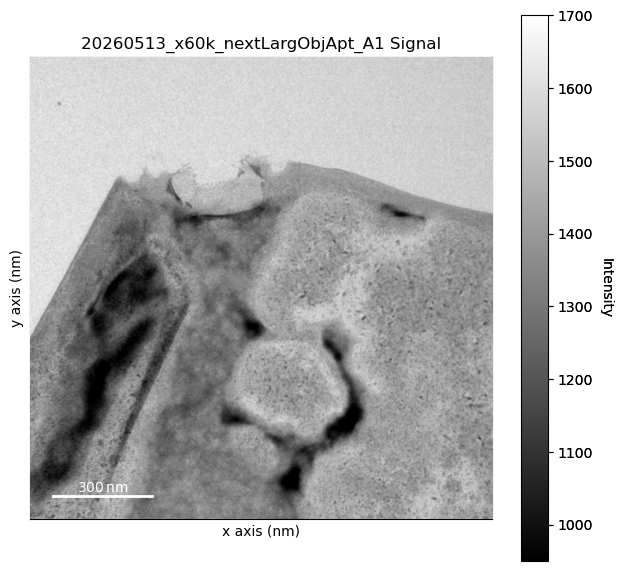

In [3]:
s3.plot(vmin=950, vmax=1700)

In [ ]:
s_r = ndimage.rotate(s3, -63)


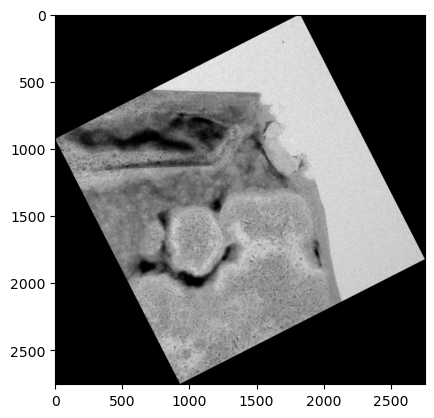

In [13]:
plt.imshow(s_r.data, vmin=950, vmax=1700, cmap='gray')

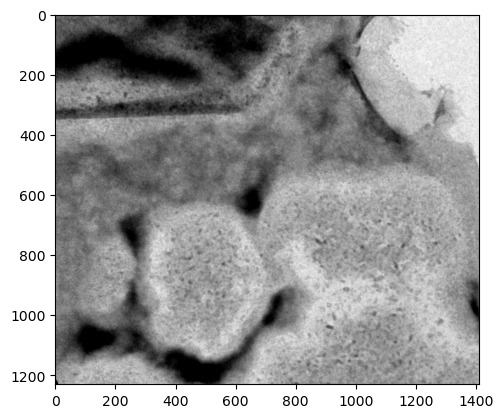

In [32]:
s_rc = s_r[800:2030, 550:1960]
plt.imshow(s_rc.data, vmin=1000, vmax=1650, cmap='gray')

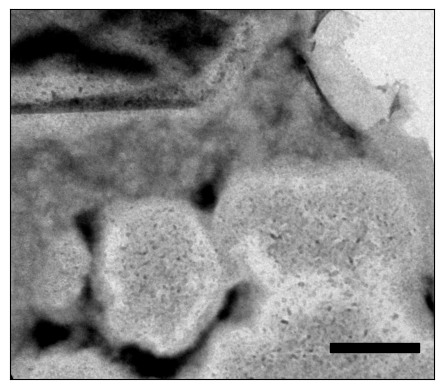

In [43]:
ext= [0, 0.6795962452888489* s_rc.shape[1], 0, 0.6795962452888489* s_rc.shape[0]]

fig,ax1=plt.subplots()
ax1.imshow(X=s_rc.data,extent=ext,vmin=1000,vmax=1650,cmap='gray')
ax1.set_xticks([])
ax1.set_yticks([])
fontprops = fm.FontProperties(size=16)
scalebar = AnchoredSizeBar(
    transform=ax1.transData,
    size=200, # corresponds to 500 nm in the image
    label='',
    loc='center',                # irrelevant when using bbox_to_anchor
    frameon=False,
    color="k",
    size_vertical=20,
    label_top=False,
    fontproperties=fontprops,
    bbox_to_anchor=(0.86, 0.05), # (x, y) in axes coordinates
    bbox_transform=ax1.transAxes # interpret the coords in axes space
)
scalebar.txt_label._text.set_path_effects([patheffects.withStroke(linewidth=0.5, foreground='white')])

ax1.add_artist(scalebar)
fig.savefig('TEMBF.svg', 
            bbox_inches='tight',   # Remove extra whitespace
            pad_inches=0,          # No padding
            dpi=950)

# HAADF intensities


In [41]:
area = 22528.0348 #nm^2

background = [
    5431082072.0000,
    5428379180.0000,
    5515658298.0000,
    5504057100.0000,
    5556028113.0000
    ]

unaltered = [
    7011624049.0000,
    6889592241.0000,
    6913226993.0000,
    6731162969.0000,
    6776417636.0000
    ]

altered = [
    6388270237.0000,
    6528470482.0000,
    6442514628.0000,
    6656447001.0000,
    6551690736.0000
    ]


In [42]:
unaltered_mean_nm2= np.mean(unaltered)/area
unaltered_std_nm2 = np.std(unaltered)/area
background_mean_nm2 = np.mean(background)/area
background_std_nm2 = np.std(background)/area
altered_mean_nm2 = np.mean(altered)/area
altered_std_nm2 = np.std(altered)/area

In [43]:
print("Unaltered mean:", unaltered_mean_nm2)
print("Unaltered std:", unaltered_std_nm2)
print("Background mean:", background_mean_nm2)  
print("Background std:", background_std_nm2)
print("Altered mean:", altered_mean_nm2)
print("Altered std:", altered_std_nm2)

Unaltered mean: 304704.99706436886
Unaltered std: 4447.191003291588
Background mean: 243565.00694858658
Background std: 2214.153054473762
Altered mean: 289127.6879952263
Altered std: 4108.713050418543


In [46]:
altered_corrected = altered_mean_nm2 - background_mean_nm2
unaltered_corrected = unaltered_mean_nm2 - background_mean_nm2

In [47]:
print(f"Unaltered corrected: {unaltered_corrected:.2e} integrated counts/nm^2")
print(f"Altered corrected: {altered_corrected:.2e} integrated counts/nm^2")

Unaltered corrected: 6.11e+04 integrated counts/nm^2
Altered corrected: 4.56e+04 integrated counts/nm^2


In [48]:
print(f"Unaltered per unit area: {unaltered_mean_nm2:.2e}, std: {unaltered_std_nm2:.2e}")
print(f"Altered per unit area: {altered_mean_nm2:.2e}, std: {altered_std_nm2:.2e}")

Unaltered per unit area: 3.05e+05, std: 4.45e+03
Altered per unit area: 2.89e+05, std: 4.11e+03


In [51]:
1- altered_mean_nm2/unaltered_mean_nm2

0.05112259142193143

In [50]:
unaltered_mean_nm2/altered_mean_nm2

1.053876919146532

In [ ]:

import numpy as np
from scipy import stats
import pandas as pd


area =125039.9770 #nm^2
# Load the CSV files saved from Fiji's histogram list
data_a = pd.read_csv("/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/Histogram_altered.csv")
data_u = pd.read_csv("/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/Histogram_unaltered.csv")
data_b = pd.read_csv("/Users/jonasfsimonsen/Documents/NTNU/5klasse/Masteroppgave/DataHandling/EDS/Histogram_background.csv")

# Recreate the individual pixel population from the Value and Count columns of the histograms 
raw_pixels_altered = np.repeat(data_a.iloc[:, 1], data_a.iloc[:, 2].astype(int))
raw_pixels_unaltered = np.repeat(data_u.iloc[:, 1], data_u.iloc[:, 2].astype(int))
raw_pixels_background = np.repeat(data_b.iloc[:, 1], data_b.iloc[:, 2].astype(int))

print(len(raw_pixels_altered), "pixels in altered region")

# Input your measured background mean gray value
background_value = np.mean(raw_pixels_background)/area #integrated counts per nm^2 of the background region

# Convert to NumPy arrays
array_a = np.array(raw_pixels_altered)/area
array_b = np.array(raw_pixels_unaltered)/area


# Apply background correction to every individual pixel
corrected_a = array_a - background_value
corrected_b = array_b - background_value

# Run the Unpaired t-test (Welch's t-test)
# equal_var=False is highly recommended for experimental/image data
t_stat, p_value = stats.ttest_ind(corrected_a, corrected_b, equal_var=False)

# Output the results and interpretation
print("--- STEM HAADF Statistical Analysis ---")
print(f"Region A Corrected Mean: {np.mean(corrected_a):.2f}")
print(f"Region B Corrected Mean: {np.mean(corrected_b):.2f}")
print(f"T-statistic:             {t_stat:.4f}")
print(f"P-value:                 {p_value:.10e}")
print("---------------------------------------")

alpha = 0.05
if p_value < alpha:
    print(f"Result: STATISTICALLY SIGNIFICANT (p < {alpha})")
    print("Conclusion: There is a genuine physical difference in electron scattering between the regions.")
else:
    print(f"Result: NOT STATISTICALLY SIGNIFICANT (p >= {alpha})")
    print("Conclusion: The difference in intensity could be caused by random image noise.")


19321 pixels in altered region
--- STEM HAADF Statistical Analysis ---
Region A Corrected Mean: 2.42
Region B Corrected Mean: 3.18
T-statistic:             -120.3846
P-value:                 0.0000000000e+00
---------------------------------------
Result: STATISTICALLY SIGNIFICANT (p < 0.05)
Conclusion: There is a genuine physical difference in electron scattering between the regions.
